In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
data=pd.read_csv("email_data.csv")

In [36]:
data.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [37]:
data.columns

Index(['label', 'text'], dtype='object')

In [38]:
data.shape

(83448, 2)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [40]:
data.isnull().sum()

label    0
text     0
dtype: int64

In [41]:
X = data['text']        
y = data['label']   

In [54]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [11]:
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)


In [12]:
model = MultinomialNB()
model.fit(X_train_cv, y_train)
"Model trained successfully."

'Model trained successfully.'

In [13]:
y_pred = model.predict(X_test_cv)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9761533852606351
Confusion Matrix:
 [[7831  107]
 [ 291 8461]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      7938
           1       0.99      0.97      0.98      8752

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



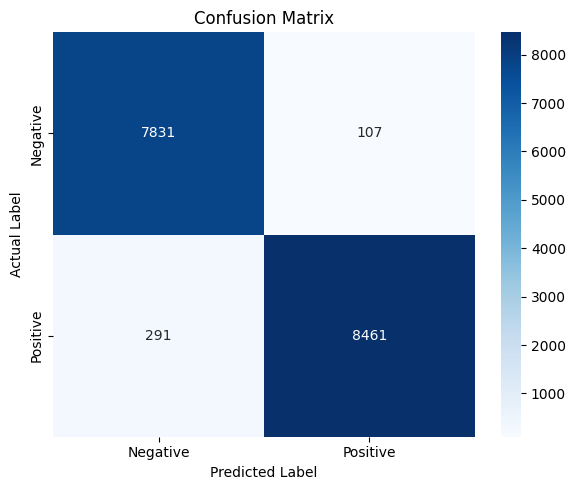

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

# Save image for LinkedIn
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [20]:
sample = ["Congratulations! You have won a $1000 gift card. Click here to claim now."]
sample_vector = cv.transform(sample)
print("Prediction:", model.predict(sample_vector))

Prediction: [1]


In [21]:
pickle.dump(model, open("naive_bayes_model.pkl", "wb"))
pickle.dump(cv, open("vectorizer.pkl", "wb"))
print("model saved as 'naive_bayes_model.pkl' ")

model saved as 'naive_bayes_model.pkl' 
